<a href="https://colab.research.google.com/github/aseel1/Deep-learning/blob/main/HW-2/HW2_322512690_21239353_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework 2**  - Deep Learning Winter 2024

Student 1: Rajaa Haj 322512690

Student 2: Aseel Shaheen 212393532



**First step we load the data from the torchvision libary and split the data into Test and training and validation**

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F  # Added F for functional API


# Step 1: Load CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize the dataset
])
# Load training and test datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Step 2: Split the training dataset into training and validation sets
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(train_dataset))  # 80% for training
val_size = len(train_dataset) - train_size  # Remaining 20% for validation

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


**Task1 : building the first CNN as ordered we made an img to describe and understand what really happen **

In [ ]:

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 10)  # CIFAR-10 has 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.fc1(x)
        return x


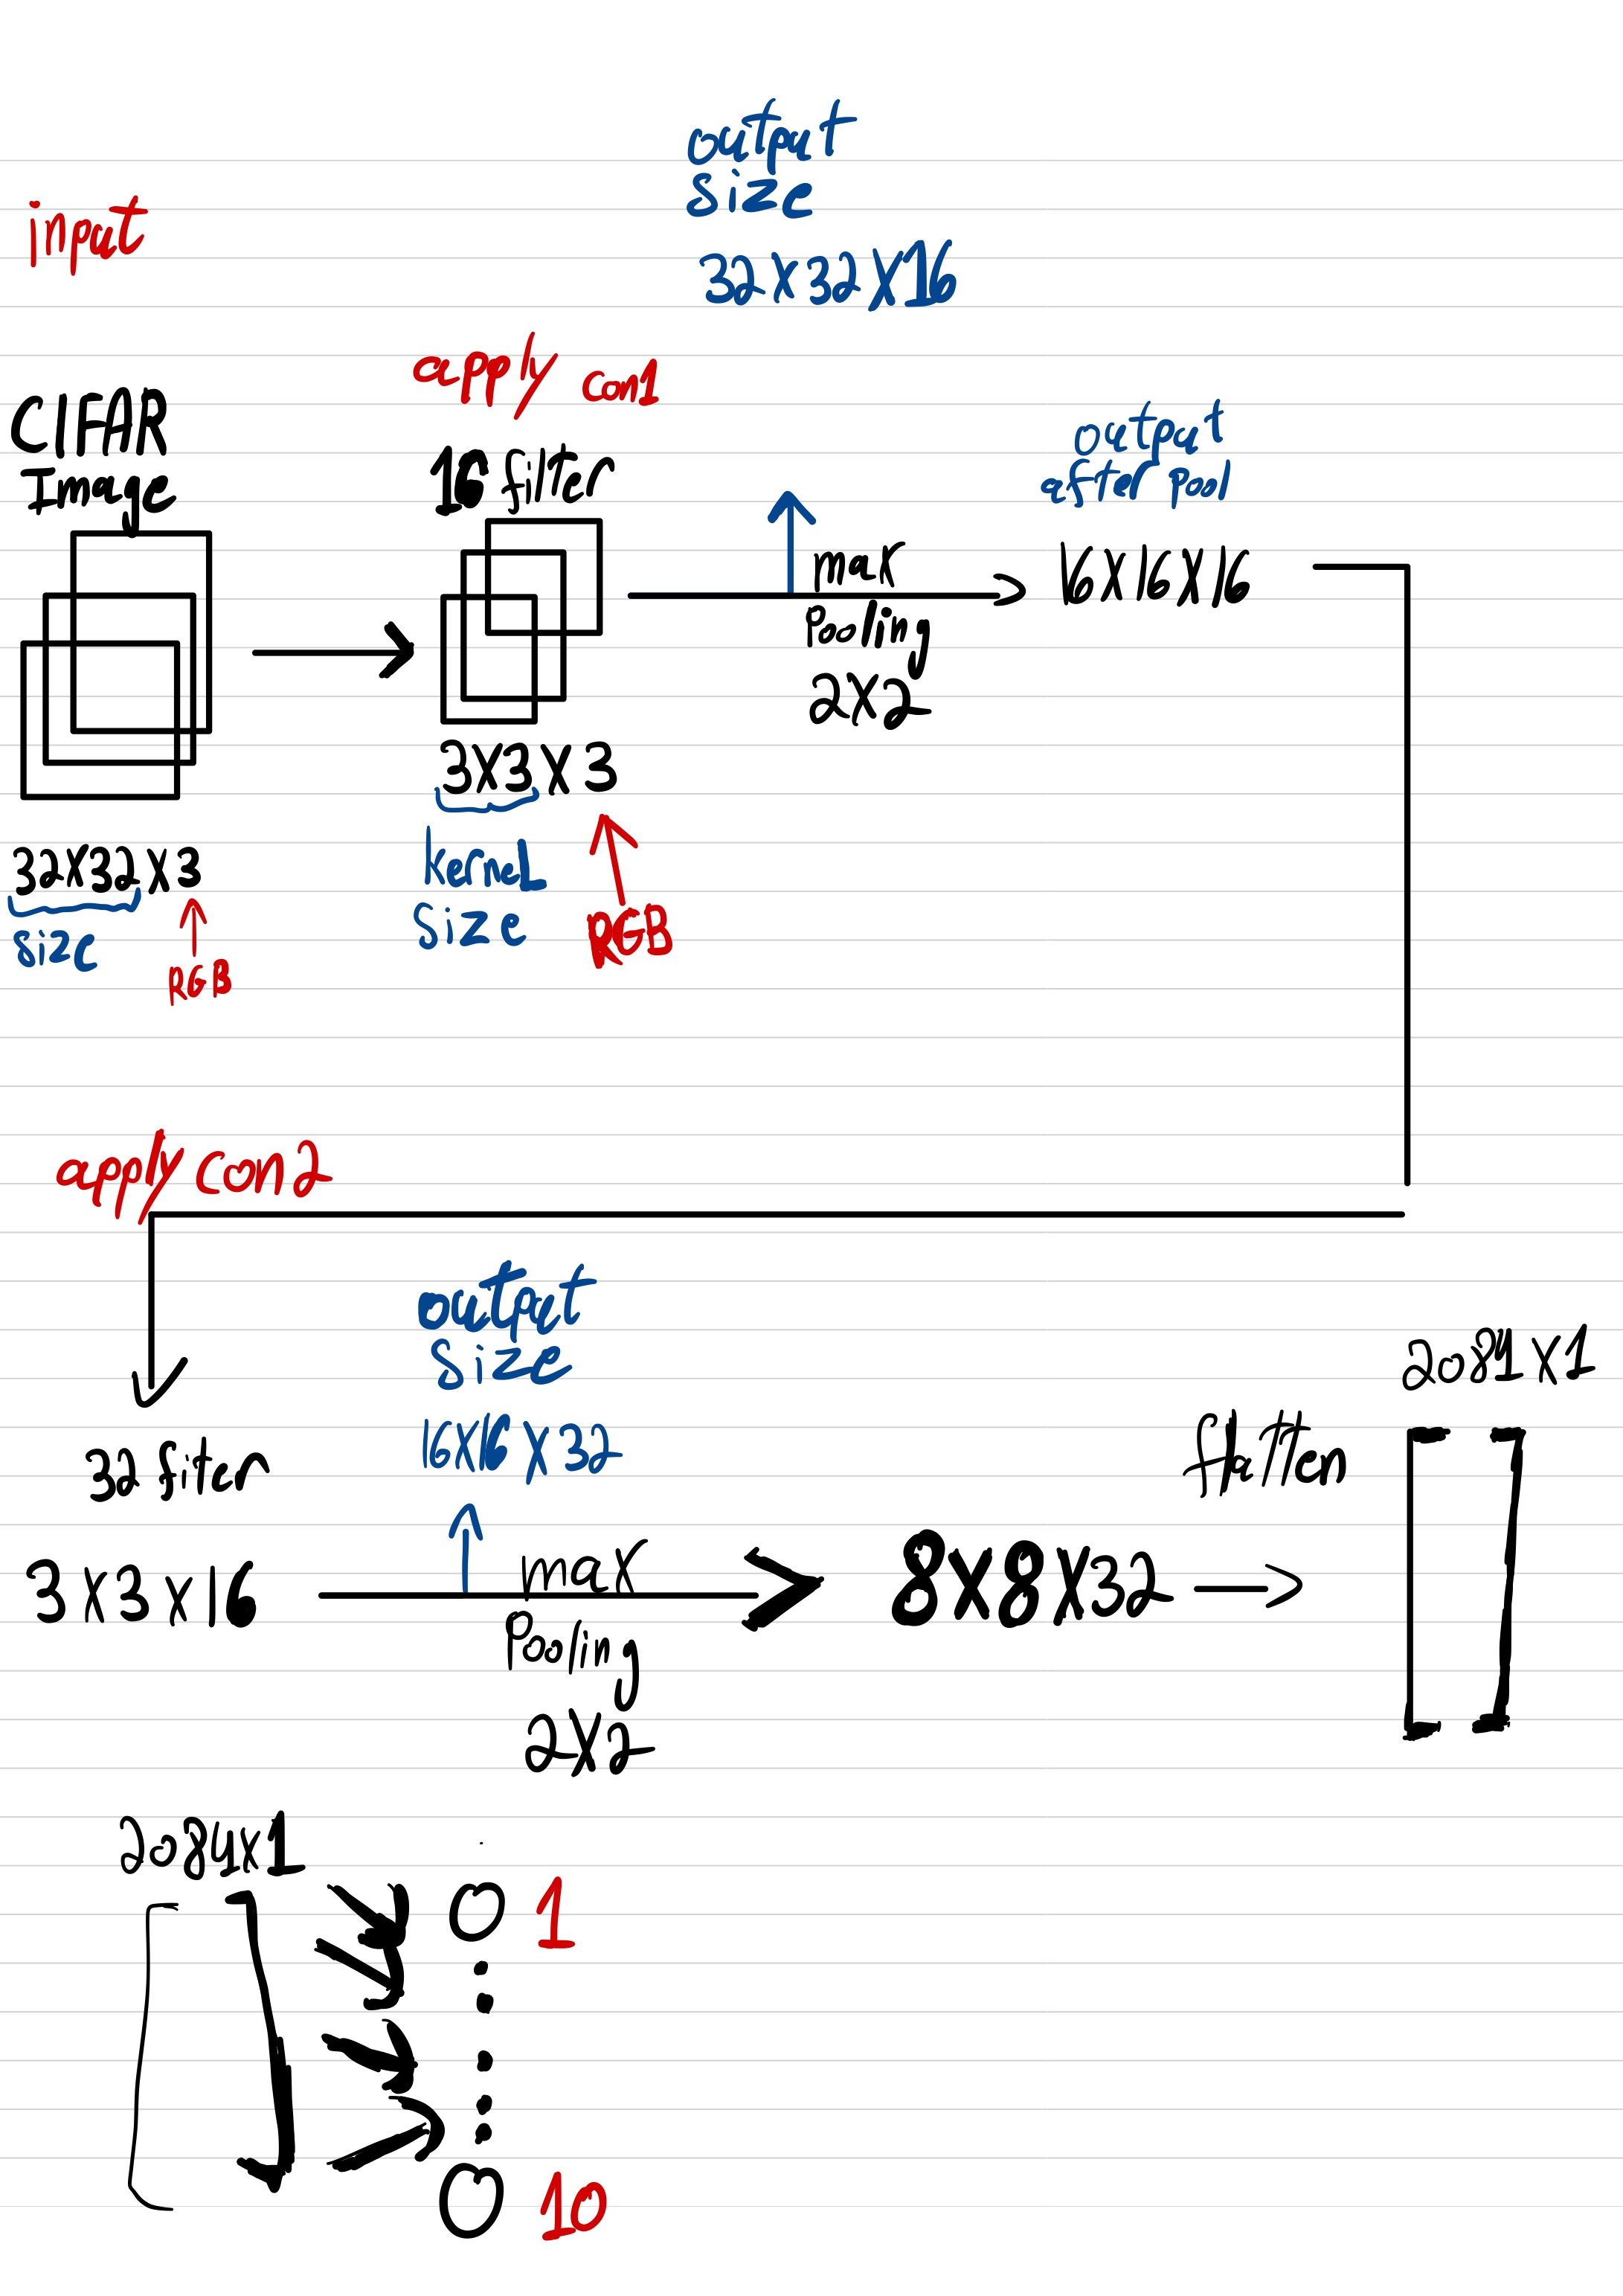

**Made an function for training the model with 10 epochcs which gets the appropirate net (according to task) **

In [ ]:
def train_and_validate(net, criterion, optimizer, train_loader, val_loader, num_epochs=10):
    best_val_accuracy = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        # Training phase
        net.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(train_loader, 0):
            inputs, labels = data

            optimizer.zero_grad()

            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total

        # Validation phase
        net.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for data in val_loader:
                inputs, labels = data
                outputs = net(inputs)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total

        # Save the best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = net.state_dict()

        print(f'Epoch {epoch + 1}/{num_epochs} Loss: {running_loss / len(train_loader):.3f} Train Accuracy: {train_accuracy:.2f}% Validation Accuracy: {val_accuracy:.2f}%')

    print('Finished Training')
    net.load_state_dict(best_model_state)
    return net


**For testing the Model**

In [ ]:
def test_model(net, test_loader):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy of the best model on the 10000 test images: {100 * correct / total:.2f}%')


**Results for the first CNN task 1 :**

In [ ]:
net = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)


Epoch 1/10 Loss: 1.503 Train Accuracy: 46.82% Validation Accuracy: 55.07%
Epoch 2/10 Loss: 1.191 Train Accuracy: 58.22% Validation Accuracy: 61.23%
Epoch 3/10 Loss: 1.067 Train Accuracy: 63.06% Validation Accuracy: 63.69%
Epoch 4/10 Loss: 0.987 Train Accuracy: 65.79% Validation Accuracy: 65.32%
Epoch 5/10 Loss: 0.936 Train Accuracy: 67.59% Validation Accuracy: 65.53%
Epoch 6/10 Loss: 0.890 Train Accuracy: 69.30% Validation Accuracy: 64.92%
Epoch 7/10 Loss: 0.856 Train Accuracy: 70.30% Validation Accuracy: 66.48%
Epoch 8/10 Loss: 0.824 Train Accuracy: 71.55% Validation Accuracy: 65.78%
Epoch 9/10 Loss: 0.797 Train Accuracy: 72.43% Validation Accuracy: 67.54%
Epoch 10/10 Loss: 0.774 Train Accuracy: 73.33% Validation Accuracy: 67.73%
Finished Training
Accuracy of the best model on the 10000 test images: 67.47%


**Task 2: deffing the new CNN with extra Layers**

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # New layer
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # New layer
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # Updated input size

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))  # New layer
        x = self.pool(F.relu(self.conv4(x)))  # New layer
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x


In [ ]:
net = DeepCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)


Epoch 1/10 Loss: 1.584 Train Accuracy: 41.70% Validation Accuracy: 51.83%
Epoch 2/10 Loss: 1.225 Train Accuracy: 56.06% Validation Accuracy: 59.64%
Epoch 3/10 Loss: 1.032 Train Accuracy: 63.41% Validation Accuracy: 64.52%
Epoch 4/10 Loss: 0.900 Train Accuracy: 68.30% Validation Accuracy: 67.82%
Epoch 5/10 Loss: 0.797 Train Accuracy: 72.02% Validation Accuracy: 69.48%
Epoch 6/10 Loss: 0.717 Train Accuracy: 75.19% Validation Accuracy: 70.55%
Epoch 7/10 Loss: 0.641 Train Accuracy: 77.70% Validation Accuracy: 71.62%
Epoch 8/10 Loss: 0.575 Train Accuracy: 80.16% Validation Accuracy: 71.26%
Epoch 9/10 Loss: 0.517 Train Accuracy: 81.98% Validation Accuracy: 72.11%
Epoch 10/10 Loss: 0.464 Train Accuracy: 83.94% Validation Accuracy: 71.35%
Finished Training
Accuracy of the best model on the 10000 test images: 70.73%


Task 3 CNN

In [ ]:
class ModifiedCNN(nn.Module):
    def __init__(self):
        super(ModifiedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2, padding=2)  # Updated kernel size and stride
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=2)  # Updated kernel size and stride
        self.fc1 = nn.Linear(32 * 2 * 2, 10)  # Adjusted based on new output size

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = self.fc1(x)
        return x


In [ ]:
net = ModifiedCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)

Epoch 1/10 Loss: 1.663 Train Accuracy: 39.92% Validation Accuracy: 48.18%
Epoch 2/10 Loss: 1.371 Train Accuracy: 51.42% Validation Accuracy: 54.10%
Epoch 3/10 Loss: 1.267 Train Accuracy: 55.01% Validation Accuracy: 54.24%
Epoch 4/10 Loss: 1.194 Train Accuracy: 57.71% Validation Accuracy: 57.44%
Epoch 5/10 Loss: 1.142 Train Accuracy: 59.74% Validation Accuracy: 59.00%
Epoch 6/10 Loss: 1.103 Train Accuracy: 61.09% Validation Accuracy: 59.62%
Epoch 7/10 Loss: 1.067 Train Accuracy: 62.49% Validation Accuracy: 60.41%
Epoch 8/10 Loss: 1.043 Train Accuracy: 63.32% Validation Accuracy: 60.95%
Epoch 9/10 Loss: 1.017 Train Accuracy: 64.15% Validation Accuracy: 61.13%
Epoch 10/10 Loss: 0.998 Train Accuracy: 64.82% Validation Accuracy: 61.37%
Finished Training
Accuracy of the best model on the 10000 test images: 60.87%


In [ ]:
class DeepCNN_AvgPool(nn.Module):
    def __init__(self):
        super(DeepCNN_AvgPool, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)  # Changed to Average Pooling
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # Additional layer
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)  # Additional layer
        self.fc1 = nn.Linear(128 * 2 * 2, 10)  # Updated for additional layers

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x


In [ ]:
net = DeepCNN_AvgPool()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

net = train_and_validate(net, criterion, optimizer, train_loader, val_loader)
test_model(net, test_loader)

Epoch 1/10 Loss: 1.716 Train Accuracy: 37.05% Validation Accuracy: 45.89%
Epoch 2/10 Loss: 1.401 Train Accuracy: 49.32% Validation Accuracy: 54.21%
Epoch 3/10 Loss: 1.264 Train Accuracy: 54.49% Validation Accuracy: 57.38%
Epoch 4/10 Loss: 1.166 Train Accuracy: 58.21% Validation Accuracy: 59.99%
Epoch 5/10 Loss: 1.083 Train Accuracy: 61.52% Validation Accuracy: 60.76%
Epoch 6/10 Loss: 1.024 Train Accuracy: 63.52% Validation Accuracy: 63.88%
Epoch 7/10 Loss: 0.968 Train Accuracy: 65.68% Validation Accuracy: 65.35%
Epoch 8/10 Loss: 0.909 Train Accuracy: 67.86% Validation Accuracy: 65.53%
Epoch 9/10 Loss: 0.867 Train Accuracy: 69.38% Validation Accuracy: 66.34%
Epoch 10/10 Loss: 0.826 Train Accuracy: 70.77% Validation Accuracy: 67.56%
Finished Training
Accuracy of the best model on the 10000 test images: 67.65%


**Question 2 .**

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [3]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import glob
from torchvision.io import read_image
from PIL import Image
import os
from torchvision.transforms.functional import to_pil_image

class TestDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_paths = glob.glob(f"{image_dir}/*")  # Get all image paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = read_image(image_path)  # Load the image as a tensor
        image = to_pil_image(image)  # Convert tensor to PIL Image
        if self.transform:
            image = self.transform(image)  # Apply transformations
        return image, image_path  # Return the processed image and its path


Pre-process the data, load it and scale it and normalize it .

In [4]:
# Define transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match input size
    transforms.ToTensor(),  # Convert to tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize RGB channels
])

# Paths to train and test folders
train_dir = '/content/drive/MyDrive/Train'
test_dir = '/content/drive/MyDrive/Test'

# Load Train Dataset
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Load Test Dataset using TestDataset class
test_dataset = TestDataset(test_dir, transform=data_transforms)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


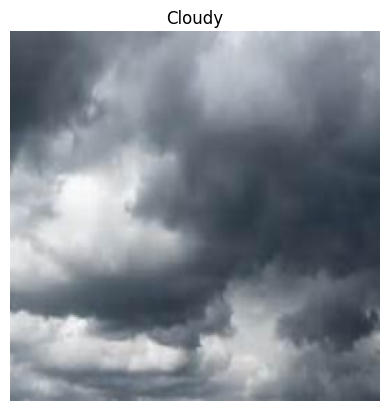

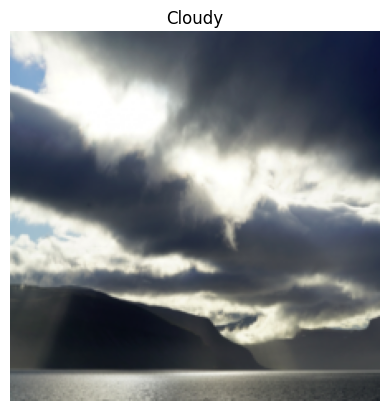

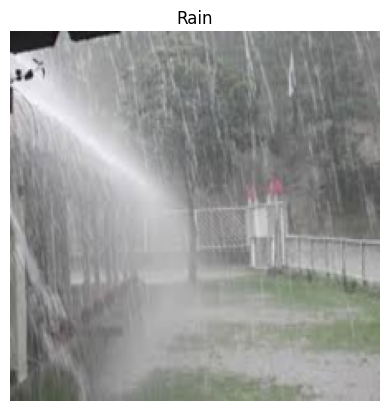

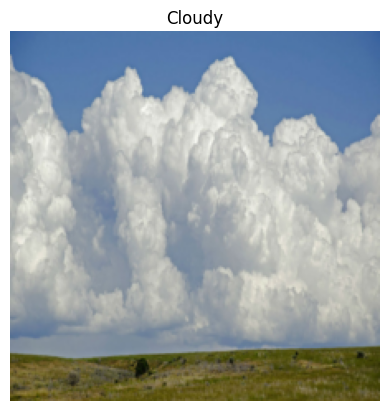

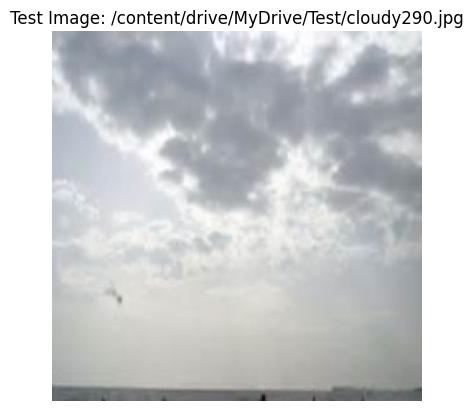

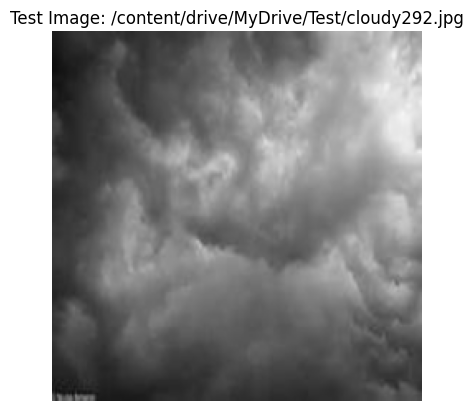

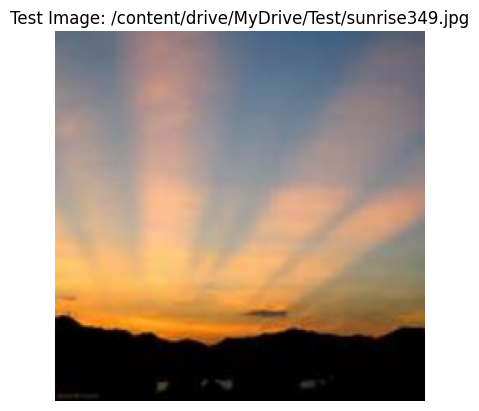

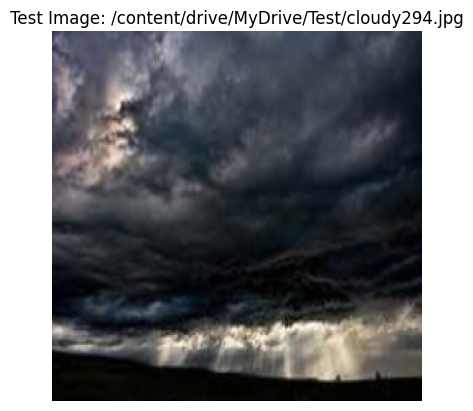

In [5]:
# Display a few images to verify
def imshow(img, title):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Visualize some training images
class_names = train_dataset.classes
dataiter = iter(train_loader)
images, labels = next(dataiter)

for i in range(4):  # Show 4 training images
    imshow(images[i], title=class_names[labels[i]])

# Visualize some test images
testiter = iter(test_loader)
test_images, test_paths = next(testiter)

for i in range(4):  # Show 4 test images
    imshow(test_images[i], title=f"Test Image: {test_paths[i]}")

We will use the ResNet model we learned in Clas

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

model = models.resnet18(pretrained=True)

#adapt the model to our needs output 4 classes (sun,cloud,....)
num_features = model.fc.in_features  # Get the number of input features to the FC layer
model.fc = nn.Linear(num_features, 4)  # Replace the FC layer with 4 outputs

# Step 3: Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Step 4: Fine-tune the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Training function
def train_model(model, criterion, optimizer, train_loader, num_epochs=10):
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_accuracy = 100 * correct / total
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {running_loss / len(train_loader):.3f}, Accuracy: {train_accuracy:.2f}%")



    return model

# Step 5: Train and Validate the Model
# Assuming `train_loader` and `val_loader` are defined
trained_model = train_model(model, criterion, optimizer, train_loader)

# Step 6: Evaluate on Test Data
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += inputs.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

# Evaluate
evaluate_model(trained_model, test_loader)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]


Epoch 1/10, Loss: 0.453, Accuracy: 86.48%
Epoch 2/10, Loss: 0.299, Accuracy: 90.99%
Epoch 3/10, Loss: 0.282, Accuracy: 93.43%
Epoch 4/10, Loss: 0.158, Accuracy: 94.65%
Epoch 5/10, Loss: 0.105, Accuracy: 96.71%
Epoch 6/10, Loss: 0.093, Accuracy: 96.43%
Epoch 7/10, Loss: 0.132, Accuracy: 95.87%
Epoch 8/10, Loss: 0.203, Accuracy: 93.05%
Epoch 9/10, Loss: 0.160, Accuracy: 94.74%
Epoch 10/10, Loss: 0.123, Accuracy: 95.96%


RuntimeError: The size of tensor a (28) must match the size of tensor b (32) at non-singleton dimension 0